OBJECTIVE 2 — Price Prediction Models

In [10]:
from google.colab import files
uploaded = files.upload()

Saving processed_files.zip to processed_files (1).zip


In [12]:
import zipfile

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/processed")

In [13]:
import pandas as pd
import os

data_path = "/content/processed"

coin_data = {}

for file in os.listdir(data_path):
    if file.endswith(".csv"):
        coin = file.split("_processed")[0]
        df = pd.read_csv(os.path.join(data_path, file), index_col=0, parse_dates=True)
        coin_data[coin] = df

print("Loaded coins:", list(coin_data.keys()))

Loaded coins: ['coin_Aave', 'coin_NEM', 'coin_Uniswap', 'coin_Solana', 'coin_EOS', 'coin_Iota', 'coin_WrappedBitcoin', 'coin_ChainLink', 'coin_Cardano', 'coin_XRP', 'coin_Bitcoin', 'coin_Stellar', 'coin_Litecoin', 'coin_Monero', 'coin_Ethereum', 'coin_Tether', 'coin_USDCoin', 'coin_Cosmos', 'coin_BinanceCoin', 'coin_CryptocomCoin', 'coin_Polkadot', 'coin_Tron', 'coin_Dogecoin']


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

results = {}

for coin, data in coin_data.items():
    df = data

    train_size = int(len(df) * 0.8)
    train = df[:train_size]
    test = df[train_size:]

    X_train = train[['MA7','MA30','Volatility']]
    y_train = train['Close']

    X_test = test[['MA7','MA30','Volatility']]
    y_test = test['Close']

    lr = LinearRegression().fit(X_train, y_train)
    rf = RandomForestRegressor(n_estimators=50).fit(X_train, y_train)

    y_lr = lr.predict(X_test)
    y_rf = rf.predict(X_test)

    results[coin] = {
        "LR_RMSE": np.sqrt(mean_squared_error(y_test, y_lr)),
        "RF_RMSE": np.sqrt(mean_squared_error(y_test, y_rf)),
        "LR_MAE": mean_absolute_error(y_test, y_lr),
        "RF_MAE": mean_absolute_error(y_test, y_rf),
    }

In [16]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="RF_RMSE")

results_df

,LR_RMSE,RF_RMSE,LR_MAE,RF_MAE
coin_USDCoin,0.000968,0.000833,0.000719,0.000435
coin_Tether,0.001959,0.002151,0.001093,0.001275
coin_Tron,0.008426,0.016677,0.005341,0.008928
coin_CryptocomCoin,0.013429,0.030442,0.009535,0.020901
coin_Stellar,0.028244,0.033619,0.014678,0.019353
coin_NEM,0.032382,0.043516,0.017035,0.020581
coin_Dogecoin,0.026759,0.139141,0.008123,0.057859
coin_XRP,0.069501,0.143893,0.034252,0.056396
coin_Iota,0.119902,0.165740,0.072174,0.100716
coin_Cardano,0.106389,0.528794,0.067257,0.367019


In [17]:
results_df.to_csv("results.csv")

In [18]:
from google.colab import files
files.download("/content/results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

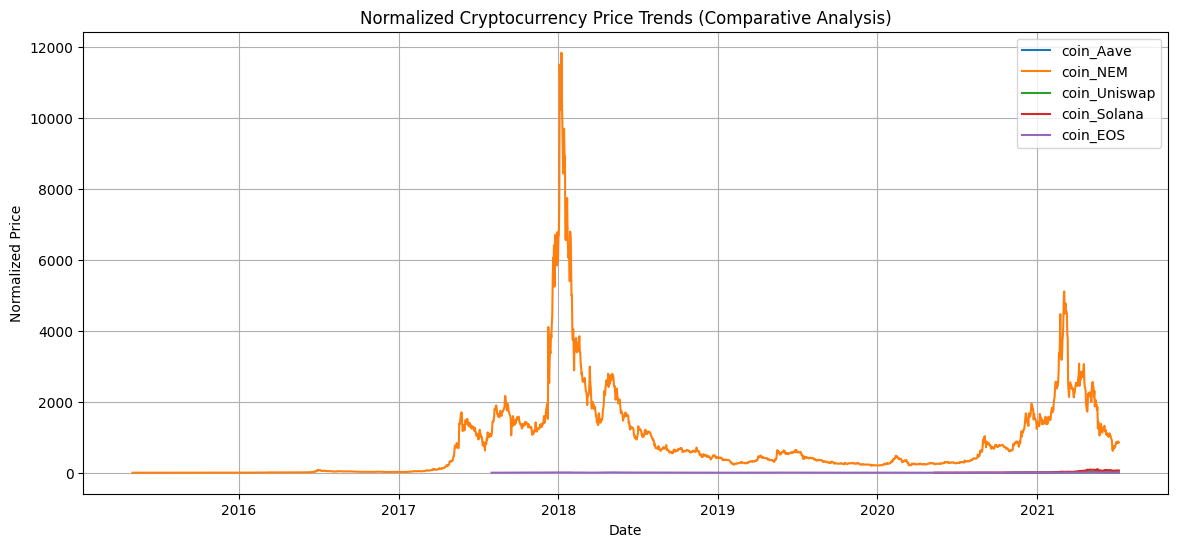

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

top_coins = list(coin_data.keys())[:5]   # FIX

for coin in top_coins:
    df = coin_data[coin]

    normalized = df['Close'] / df['Close'].iloc[0]
    plt.plot(normalized, label=coin)

plt.legend()
plt.grid(True)
plt.title("Normalized Cryptocurrency Price Trends (Comparative Analysis)")
plt.ylabel("Normalized Price")
plt.xlabel("Date")
plt.show()

In [22]:
combined = pd.DataFrame()

for coin, data in coin_data.items():
    combined[coin] = data['Close']

combined = combined.ffill().dropna()

corr = combined.corr()
corr

,coin_Aave,coin_NEM,coin_Uniswap,coin_Solana,coin_EOS,coin_Iota,coin_WrappedBitcoin,coin_ChainLink,coin_Cardano,coin_XRP,...,coin_Monero,coin_Ethereum,coin_Tether,coin_USDCoin,coin_Cosmos,coin_BinanceCoin,coin_CryptocomCoin,coin_Polkadot,coin_Tron,coin_Dogecoin
coin_Aave,1.000000,0.558994,0.911701,0.654970,0.712029,0.827813,0.842911,0.903093,0.805882,0.606198,...,0.745238,0.835769,0.112545,0.138744,0.896367,0.744395,0.680490,0.897859,0.699922,0.572693
coin_NEM,0.558994,1.000000,0.539302,0.044848,0.261099,0.538903,0.690327,0.543482,0.289746,0.159368,...,0.334156,0.226342,0.074177,0.109793,0.661934,0.302403,0.585749,0.694013,0.296330,-0.063963
coin_Uniswap,0.911701,0.539302,1.000000,0.779658,0.778059,0.943173,0.891787,0.929988,0.867221,0.732199,...,0.876752,0.877201,0.082912,0.210918,0.938160,0.902097,0.860053,0.941035,0.841933,0.659056
coin_Solana,0.654970,0.044848,0.779658,1.000000,0.785549,0.760842,0.528864,0.697321,0.900602,0.826283,...,0.866479,0.911752,-0.005341,0.142953,0.650749,0.923003,0.580192,0.619157,0.829910,0.912015
coin_EOS,0.712029,0.261099,0.778059,0.785549,1.000000,0.835715,0.619800,0.864079,0.779843,0.877698,...,0.896731,0.881023,0.042743,0.168608,0.777084,0.877219,0.624530,0.722699,0.896145,0.814295
coin_Iota,0.827813,0.538903,0.943173,0.760842,0.835715,1.000000,0.881177,0.925094,0.814487,0.816081,...,0.922146,0.826354,0.094767,0.269533,0.949793,0.928528,0.893947,0.927271,0.924639,0.639719
coin_WrappedBitcoin,0.842911,0.690327,0.891787,0.528864,0.619800,0.881177,1.000000,0.854846,0.693386,0.524108,...,0.735885,0.703616,0.108678,0.230632,0.922342,0.730834,0.874196,0.949741,0.717292,0.371935
coin_ChainLink,0.903093,0.543482,0.929988,0.697321,0.864079,0.925094,0.854846,1.000000,0.771653,0.765813,...,0.889757,0.869232,0.076376,0.170994,0.937872,0.858574,0.762785,0.913595,0.853120,0.665664
coin_Cardano,0.805882,0.289746,0.867221,0.900602,0.779843,0.814487,0.693386,0.771653,1.000000,0.714126,...,0.813067,0.921592,0.076175,0.192688,0.789853,0.881528,0.699955,0.784836,0.772435,0.802707
coin_XRP,0.606198,0.159368,0.732199,0.826283,0.877698,0.816081,0.524108,0.765813,0.714126,1.000000,...,0.887023,0.794345,0.044370,0.193043,0.678626,0.896312,0.598464,0.615050,0.928860,0.804436


In [23]:
corr.to_csv("correl.csv")

In [24]:
from google.colab import files
files.download("/content/correl.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
top_coins = list(results_df.index[:2])
print("Top coins for LSTM:", top_coins)

Top coins for LSTM: ['coin_USDCoin', 'coin_Tether']
